### Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv(
    "../data/raw/complaints.csv",
    engine="python",
    on_bad_lines="skip"
)

In [7]:
df.shape

(13902499, 18)

In [8]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2020-07-06,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotional offers",Confusing or misleading advertising about the credit card,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,Yes,NaN,3477549
2,2020-05-08,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,Yes,NaN,3642453
3,2024-01-05,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,Kindly address this issue on my credit report. I assert that this account is not mine and believe it to be fraudulent. I urge you to correct this mistake and have provided supporting documents for...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,IL,60502,NaN,Consent provided,Web,2024-01-05,Closed with non-monetary relief,Yes,NaN,8113747
4,2024-01-21,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't recognize,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,NC,27401,Servicemember,Consent not provided,Web,2024-01-21,Closed with explanation,Yes,NaN,8191825


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13902499 entries, 0 to 13902498
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.

### Create 350k subset

In [51]:
df_sample_300 = df.sample(n=350000, random_state=42)
df_sample_300.shape

(350000, 18)

### Rename columns (clean names)

In [52]:
df_sample_300.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [53]:
df_sample_300.columns = (
    df_sample_300.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("?", "", regex=False)
)

In [54]:
df_sample_300.columns.tolist()

['date_received',
 'product',
 'sub-product',
 'issue',
 'sub-issue',
 'consumer_complaint_narrative',
 'company_public_response',
 'company',
 'state',
 'zip_code',
 'tags',
 'consumer_consent_provided',
 'submitted_via',
 'date_sent_to_company',
 'company_response_to_consumer',
 'timely_response',
 'consumer_disputed',
 'complaint_id']

In [55]:
df_sample_300.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350000 entries, 9310639 to 1304897
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date_received                 350000 non-null  object
 1   product                       350000 non-null  object
 2   sub-product                   344137 non-null  object
 3   issue                         350000 non-null  object
 4   sub-issue                     328057 non-null  object
 5   consumer_complaint_narrative  92667 non-null   object
 6   company_public_response       188959 non-null  object
 7   company                       350000 non-null  object
 8   state                         348532 non-null  object
 9   zip_code                      349252 non-null  object
 10  tags                          17899 non-null   object
 11  consumer_consent_provided     297222 non-null  object
 12  submitted_via                 350000 non-null  object
 1

In [56]:
missing = (
    df_sample_300.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

tags                            332101
consumer_disputed               331116
consumer_complaint_narrative    257333
company_public_response         161041
consumer_consent_provided        52778
sub-issue                        21943
sub-product                       5863
state                             1468
zip_code                           748
date_received                        0
product                              0
issue                                0
company                              0
submitted_via                        0
date_sent_to_company                 0
company_response_to_consumer         0
timely_response                      0
complaint_id                         0
dtype: int64

In [57]:
df_sample_300["submitted_via"].value_counts()

submitted_via
Web             334650
Referral          6806
Phone             5181
Postal mail       2644
Fax                676
Web Referral        33
Email               10
Name: count, dtype: int64

### Change the subset
I am not pleased with the number of available consumer complaint narrative. I will take a different approach in the dataset.

Full dataset  
    ↓  
Filter rows with text + target  
    ↓  
Check distribution  
    ↓  
Sample 350k  
    ↓  
EDA + modeling  

In [23]:
df_filtered = df[
    df["Consumer complaint narrative"].notnull() &
    df["Product"].notnull()
]

In [24]:
df_filtered.shape

(3684679, 18)

In [25]:
df_filtered.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [27]:
df_filtered.columns = (
    df_filtered.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("?", "", regex=False)
)

In [28]:
missing = (
    df_filtered.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

consumer_disputed               3523572
tags                            3336444
company_public_response         1706382
sub-issue                        318715
sub-product                       51300
state                             12982
company_response_to_consumer          9
date_received                         0
product                               0
consumer_complaint_narrative          0
zip_code                              0
company                               0
issue                                 0
consumer_consent_provided             0
date_sent_to_company                  0
submitted_via                         0
timely_response                       0
complaint_id                          0
dtype: int64

### New Subset with 500,000 rows

In [29]:
df_sample = df_filtered.sample(n=500000, random_state=42)
df_sample.shape

(500000, 18)

In [30]:
df_sample

,date_received,product,sub-product,issue,sub-issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id
6073196,2022-06-24,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Problem with a credit reporting company's investigation into an existing problem,Investigation took more than 30 days,Hi I am submitting this XXXX XXXX this isn't any influence and this is not a third party. XXXX has low and unfair credit number for me in their report. I have 87complained times. The problem has n...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,IL,60564,NaN,Consent provided,Web,2022-06-24,Closed with non-monetary relief,Yes,NaN,5702809
3042229,2025-07-18,Debt collection,Federal student loan debt,Attempts to collect debt not owed,Debt was result of identity theft,"A federal education loan was fraudulently opened in my name. I filed an FTC Identity Theft Report, a DOE Loan Forgery Discharge Application, and submitted supporting documents. Despite this, the D...",NaN,Servicer under contract with Federal Student Aid,CA,95682,NaN,Consent provided,Web,2025-07-18,Untimely response,No,NaN,14736409
9191655,2025-07-10,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"I am writing to have the following information removed from my credit file, the items that I need deleted are going to be attached in a word document. I am a victim of identity theft. I have multi...",NaN,"EQUIFAX, INC.",OH,432XX,NaN,Consent provided,Web,2025-07-10,Closed with non-monetary relief,Yes,NaN,14558425
13112141,2023-04-26,Credit card or prepaid card,General-purpose credit card or charge card,Problem with a credit reporting company's investigation into an existing problem,Was not notified of investigation status or results,"I want this late payment remove from my account, and I never been late with this account I working so hard to pay this monthly and this is not acceptable. \nSee the documents attached.",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,33404,NaN,Consent provided,Web,2023-04-26,Closed with non-monetary relief,Yes,NaN,6895444
10083292,2025-11-19,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,I am disputing several items on my Experian credit report that appear to be inaccurate or incomplete. The details of the accounts in question are as follows : 1. Charged-Off Accounts XXXX XXXX XXX...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,Experian Information Solutions Inc.,NC,XXXXX,NaN,Consent provided,Web,2025-11-19,Closed with explanation,Yes,NaN,17362554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6413084,2020-05-27,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Problem with a credit reporting company's investigation into an existing problem,Their investigation did not fix an error on your report,XXXX should not be reporting to XXXX ; XXXX and Transunion that I am ( 30 ) days late on the XXXX partial account number XXXX. ( Please see page attached from my credit report. ) This account had...,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,28205,NaN,Consent provided,Web,2020-05-27,Closed with explanation,Yes,NaN,3670046
1410079,2020-01-21,"Credit reporting, credit repair services, or other personal consumer reports",Credit reporting,Incorrect information on your report,Personal in

### Exploratory Analysis

In [36]:
# Plot top 10 complaint product categories
top_products = df_sample["product"].value_counts().head(10)

top_products

product
Credit reporting or other personal consumer reports                             222115
Credit reporting, credit repair services, or other personal consumer reports    107990
Debt collection                                                                  55063
Checking or savings account                                                      22738
Mortgage                                                                         18835
Money transfer, virtual currency, or money service                               15097
Credit card                                                                      14877
Credit card or prepaid card                                                      14498
Student loan                                                                      8064
Vehicle loan or lease                                                             6497
Name: count, dtype: int64

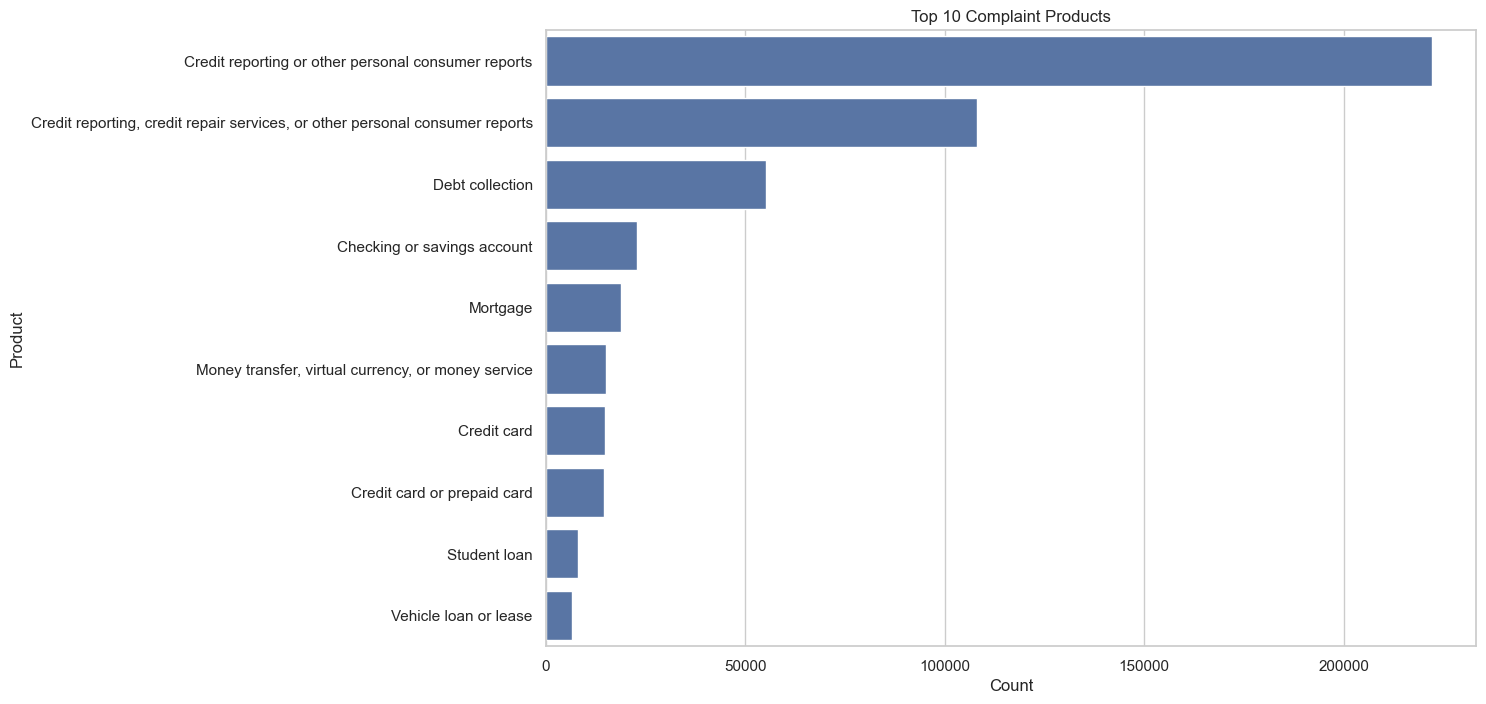

In [38]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Complaint Products")
plt.xlabel("Count")
plt.ylabel("Product")
plt.show()

In [39]:
# Plot top 10 complaint issues
top_issues = df_sample["issue"].value_counts().head(10)

top_issues

issue
Incorrect information on your report                                                160397
Improper use of your report                                                          88351
Problem with a company's investigation into an existing problem                      46060
Problem with a credit reporting company's investigation into an existing problem     33586
Attempts to collect debt not owed                                                    23365
Managing an account                                                                  12225
Written notification about debt                                                      11337
Other transaction problem                                                             7183
Trouble during payment process                                                        7153
Problem with a purchase shown on your statement                                       6575
Name: count, dtype: int64

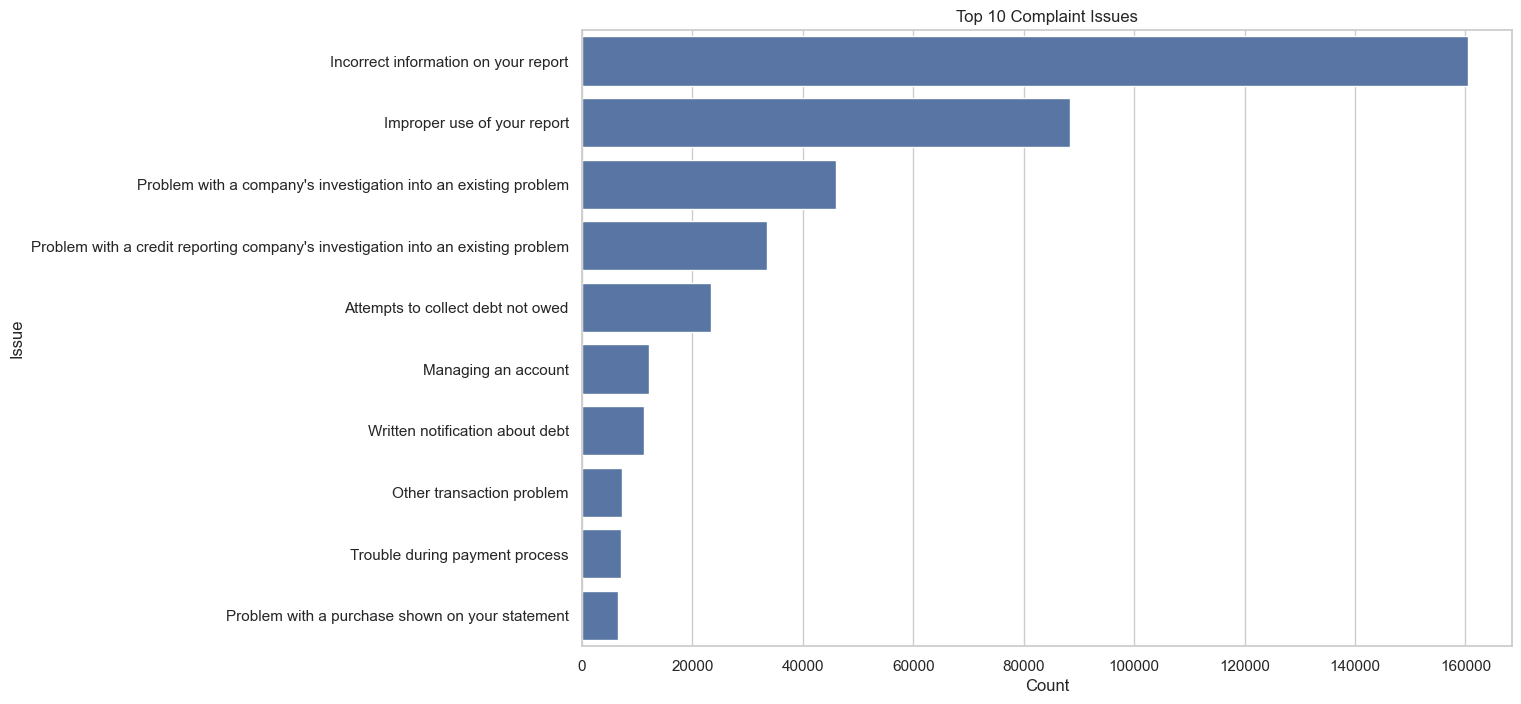

In [41]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_issues.values, y=top_issues.index)
plt.title("Top 10 Complaint Issues")
plt.xlabel("Count")
plt.ylabel("Issue")
plt.show()

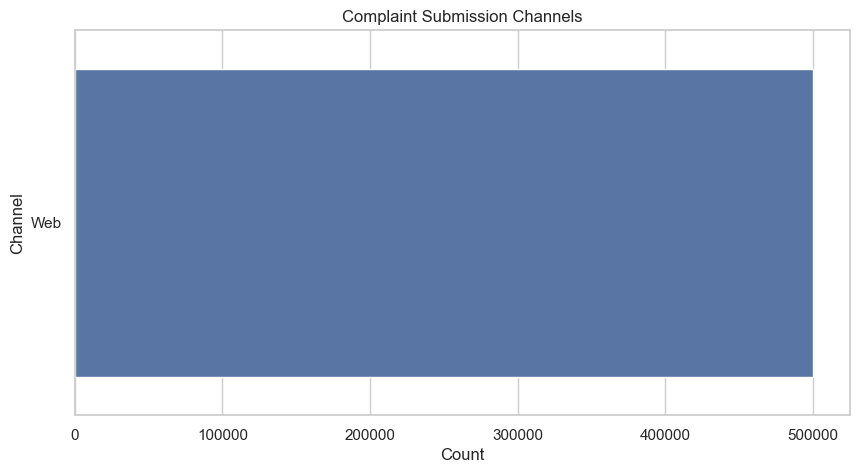

In [42]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_sample, y="submitted_via", order=df_sample["submitted_via"].value_counts().index)
plt.title("Complaint Submission Channels")
plt.xlabel("Count")
plt.ylabel("Channel")
plt.show()

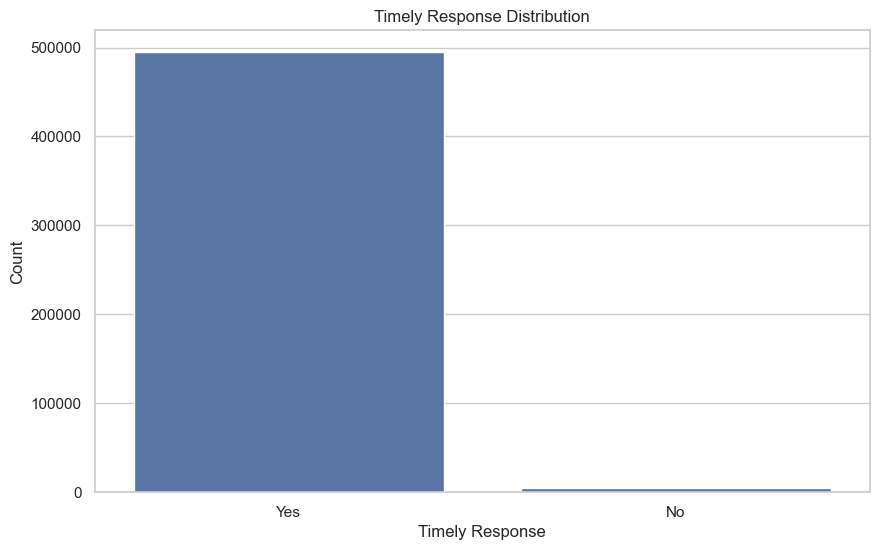

In [44]:
# Plot distribution of timely vs untimely responses
plt.figure(figsize=(10, 6))
sns.countplot(data=df_sample, x="timely_response", order=df_sample["timely_response"].value_counts().index)
plt.title("Timely Response Distribution")
plt.xlabel("Timely Response")
plt.ylabel("Count")
plt.show()

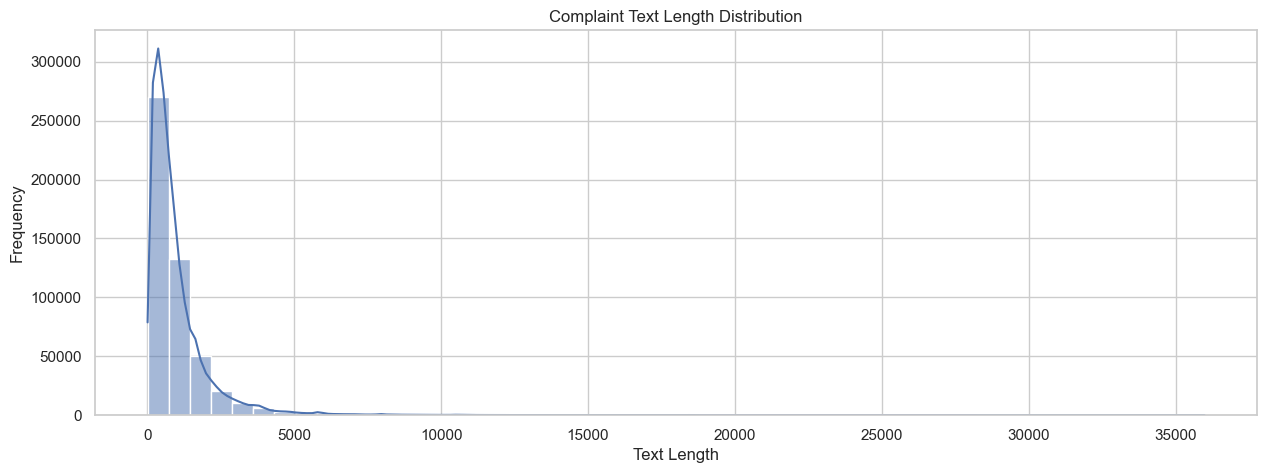

In [48]:
# Plot distribution of complaint text length
plt.figure(figsize=(15, 5))
sns.histplot(df_sample["text_length"], bins=50, kde=True)
plt.title("Complaint Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

In [35]:
df_sample["text_length"] = df_sample["consumer_complaint_narrative"].str.len()
df_sample["text_length"].describe()

count    500000.00000
mean       1015.25531
std        1302.51704
min           5.00000
25%         342.00000
50%         662.00000
75%        1209.00000
max       35984.00000
Name: text_length, dtype: float64

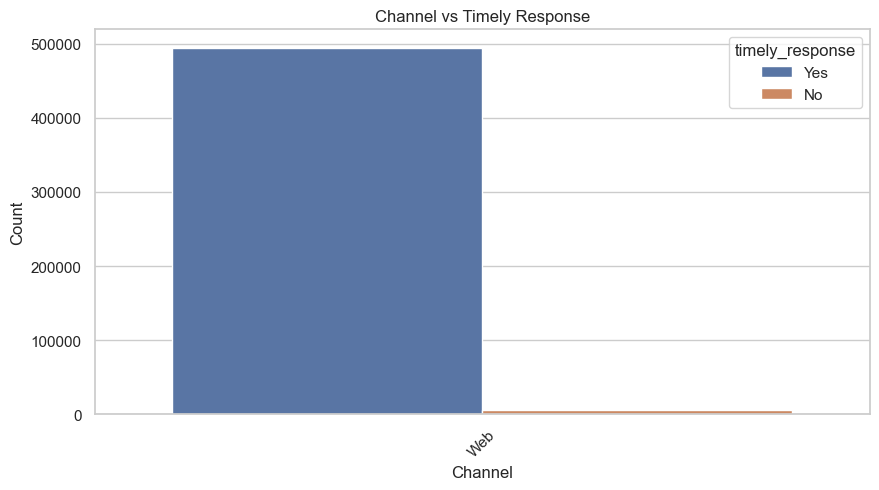

In [50]:
# Compare submission channel with timely response
plt.figure(figsize=(10, 5))
sns.countplot(data=df_sample, x="submitted_via", hue="timely_response")
plt.xticks(rotation=45)
plt.title("Channel vs Timely Response")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.show()

In [58]:
df_sample["submitted_via"].value_counts()

submitted_via
Web    500000
Name: count, dtype: int64

#### Filtering for complaint narratives introduced selection bias, as only web-submitted complaints contained text. This limits the model’s applicability across other channels.